
AYŞENUR AVŞAR 03-07-2026


1-KURULUM

In [ ]:
#Ayşenur/03-07-2026
!pip install -q transformers pillow requests

2-KÜTÜPHANELER

In [ ]:
#Ayşenur/03-07-2026
from __future__ import annotations

import io
import os
from dataclasses import dataclass

import requests
import torch
from PIL import Image
from transformers import CLIPModel, CLIPProcessor

In [ ]:
#Aysenur/07-07-2026
import os

# Kodun çalışması için kritik olan eğittiğiniz model dosyalarının kontrolü
gerekli_dosyalar = ["class_names.json", "linear_head_weights.pth"]
eksik_dosya_var_mi = False

for dosya in gerekli_dosyalar:
    if not os.path.exists(dosya):
        print(f"⚠️ Kritik Eksiklik: '{dosya}' dosyası Colab ortamında bulunamadı!")
        eksik_dosya_var_mi = True

# HATALI KISIM DÜZELTİLDİ: 'eksik_dosya_var_mikod' yerine 'eksik_dosya_var_mi' yapıldı
if eksik_dosya_var_mi:
    print("\n👉 Lütfen sol taraftaki Dosyalar (Klasör) simgesine tıklayarak ")
    print("   eğittiğiniz 'linear_head_weights.pth' ve 'class_names.json' dosyalarını yükleyin.")
else:
    print("✅ Tüm özel eğitim dosyaları hazır! Sistem kesintisiz çalışmaya hazır.")

✅ Tüm özel eğitim dosyaları hazır! Sistem kesintisiz çalışmaya hazır.


3-CLIP MODELİNİ YÜKLEME

Neden clıp modeli?

*   proje-2 dosyasında verilen probleme genel bir çözüm sağlar niteliklte olmalı şartı bulunuyordu. Çok büyük bir verisetini elimdeki GPU ve depo  şartlarıyla kısa bir sürede eğitmem mümkün değildi.Bu yüzden eğtilmiş bir Model kullanma kararı aldım . Araştırmalarıma göre projeye en uygun modellerden biriydi.CLIP Görüntü ve metni aynı vektör uzayına gömdüğü için , çalışma zamanında istediğimiz herhangi bir etiket kümesini verip görüntüye en çok benzeyeni bulabiliyoruz .




In [ ]:
#Ayşenur/03-07-2026
MODEL_ADI = "openai/clip-vit-large-patch14"

model = CLIPModel.from_pretrained(MODEL_ADI)
processor = CLIPProcessor.from_pretrained(MODEL_ADI)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)
model.eval()  # Sadece çıkarım (inference) yapacağız, eğitim değil.

print(f"CLIP modeli yüklendi, cihaz: {device}")

config.json:   0%|          | 0.00/4.52k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/905 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/961k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

CLIP modeli yüklendi, cihaz: cuda


4-GÖRÜNTÜ YÜKLEME FONKSİYONU

In [ ]:
#Ayşenur/03-07-2026
def load_image(source: str) -> Image.Image:
    """Bir URL veya yerel dosya yolundan görüntüyü yükler.

    Args:
        source: "http://" veya "https://" ile başlıyorsa web URL'si olarak,
            aksi halde yerel bir dosya yolu olarak yorumlanır.

    Raises:
        ValueError: Kaynak geçerli bir görüntüye çözümlenemezse.
    """
    is_url = source.startswith("http://") or source.startswith("https://")

    try:
        if is_url:
            response = requests.get(source, timeout=10)
            response.raise_for_status()
            image = Image.open(io.BytesIO(response.content))
        else:
            if not os.path.isfile(source):
                raise ValueError(f"Dosya bulunamadı: {source}")
            image = Image.open(source)

        # CLIP işlemcisi RGB bekliyor; PNG'lerde alfa kanalı (RGBA) veya
        # gri tonlama (L) gelebileceği için normalize ediyoruz.
        return image.convert("RGB")

    except requests.RequestException as exc:
        raise ValueError(f"Görüntü URL'den indirilemedi: {source} ({exc})") from exc
    except OSError as exc:
        raise ValueError(f"Görüntü açılamadı/geçersiz format: {source} ({exc})") from exc


print("load_image fonksiyonu tanımlandı.")

load_image fonksiyonu tanımlandı.


5-CLIP EMBEDDİNG YARDIMCI FONKSİYONLARI



*   `get_image_features()`
*   `get_text_features()`
sarmalayıcılarının transformers sürümüne göre farklı davranmasından dolayı , embedding'leri CLIP'in alt bileşenlerini (`vision_model`/`text_model` + projeksiyon katmanları) doğrudan çağırarak hesaplıyoruz. Bu, hangi sürüm kurulu olursa olsun garanti doğru sonuç verir.



In [ ]:
#Ayşenur/03-07-2026
@dataclass(frozen=True)
class ObjectDetectionResult:
    """CLIP zero-shot sınıflandırmasının sonucunu taşıyan basit veri sınıfı."""

    label: str
    confidence: float
    top_k: list


# Tek bir şablon yerine birden fazla şablonun ortalamasını alarak
# gürültüyü azaltıyoruz (prompt ensembling).
PROMPT_SABLONLARI = [
    "a photo of a {}.",
    "a photo of the {}.",
    "a close-up photo of a {}.",
    "a picture of a {}.",
    "an image showing a {}.",
]


def _get_image_embedding(image: Image.Image) -> torch.Tensor:
    """Görüntü embedding'ini CLIP'in vision_model + visual_projection
    katmanlarını doğrudan çağırarak hesaplar. get_image_features()'ın
    transformers sürümüne göre değişen belirsiz çıktı sarmalamasına
    güvenmek yerine, projeksiyonun doğru uygulandığından emin oluyoruz.
    """
    inputs = processor(images=image, return_tensors="pt").to(device)
    vision_outputs = model.vision_model(**inputs)
    pooled_output = vision_outputs.pooler_output
    return model.visual_projection(pooled_output)


def _get_text_embedding(prompts: list[str]) -> torch.Tensor:
    """Metin embedding'ini CLIP'in text_model + text_projection
    katmanlarını doğrudan çağırarak hesaplar (bkz. _get_image_embedding
    açıklaması)."""
    inputs = processor(text=prompts, return_tensors="pt", padding=True).to(device)
    text_outputs = model.text_model(**inputs)
    pooled_output = text_outputs.pooler_output
    return model.text_projection(pooled_output)


def detect_object(image: Image.Image, candidate_labels: list, top_k: int = 5,
                   label_embeddings: torch.Tensor = None) -> ObjectDetectionResult:
    """Zero-shot obje tespiti yapar. Önceden hesaplanmış label_embeddings
    verilirse metin encoding adımını tamamen atlar (performans kazancı).
    """
    if not candidate_labels:
        raise ValueError("candidate_labels boş olamaz.")

    with torch.no_grad():
        image_features = _get_image_embedding(image)
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)

        if label_embeddings is None:
            label_embeddings = precompute_label_embeddings(candidate_labels)

        logit_scale = model.logit_scale.exp()
        logits = logit_scale * image_features @ label_embeddings.T
        probs = logits.softmax(dim=1)[0]

    scored_labels = sorted(
        zip(candidate_labels, probs.tolist()), key=lambda pair: pair[1], reverse=True
    )

    best_label, best_confidence = scored_labels[0]
    return ObjectDetectionResult(
        label=best_label,
        confidence=best_confidence,
        top_k=scored_labels[:top_k],
    )


print("detect_object fonksiyonu tanımlandı (düzeltilmiş embedding çıkarma ile).")

detect_object fonksiyonu tanımlandı (düzeltilmiş embedding çıkarma ile).


6- OWL-ViT MODELİNİ YÜKLEME (ön plan objesi lokalizasyonu)

Proje metni "görüntünün içeriğinde ön plana çıkan bir obje olacaktır" diyor. CLIP tüm görüntüyü tek bir embedding'e sıkıştırdığı için, karmaşık sahnelerde (birden fazla obje/büyük arka plan) yanlış yönlenebiliyor. OWL-ViT, açık uçlu obje tespiti yaparak önce objenin **konumunu** buluyor, biz de sadece o bölgeyi kırpıp CLIP'e veriyoruz.

In [ ]:
#Ayşenur/04-07-2026
from transformers import OwlViTProcessor, OwlViTForObjectDetection

OWLVIT_MODEL_ADI = "google/owlvit-base-patch32"

owlvit_model = OwlViTForObjectDetection.from_pretrained(OWLVIT_MODEL_ADI).to(device)
owlvit_processor = OwlViTProcessor.from_pretrained(OWLVIT_MODEL_ADI)
owlvit_model.eval()

print("OWL-ViT (obje lokalizasyonu) modeli yüklendi.")

config.json:   0%|          | 0.00/4.42k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/613M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/412 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/392 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/775 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.06M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/460 [00:00<?, ?B/s]

OWL-ViT (obje lokalizasyonu) modeli yüklendi.


7-ÖN PLAN OBJESİNİ BULUP KIRPMA FONKSİYONU

In [ ]:
#Ayşenur/04-07-2026
def _post_process_owlvit(outputs, target_sizes, threshold):
    """OwlViT son-işleme metodunun transformers sürümüne göre değişen
    konumunu (processor üzerinde mi, image_processor üzerinde mi,
    eski isimle mi) otomatik bulup çağırır.
    """
    if hasattr(owlvit_processor, "post_process_object_detection"):
        return owlvit_processor.post_process_object_detection(
            outputs, threshold=threshold, target_sizes=target_sizes
        )
    if hasattr(owlvit_processor, "image_processor") and hasattr(
        owlvit_processor.image_processor, "post_process_object_detection"
    ):
        return owlvit_processor.image_processor.post_process_object_detection(
            outputs, threshold=threshold, target_sizes=target_sizes
        )
    if hasattr(owlvit_processor, "post_process"):
        return owlvit_processor.post_process(outputs, target_sizes=target_sizes)
    raise AttributeError(
        "OwlViT için uygun bir post_process fonksiyonu bulunamadı. "
        "transformers sürümünü kontrol edin: !pip show transformers"
    )


def find_and_crop_foreground_object(image: Image.Image, candidate_labels: list, score_threshold: float = 0.05) -> Image.Image:
    """OWL-ViT ile görüntüdeki en belirgin ön plan objesini bulur ve kırpar.

    Seçim kriteri sadece ham güven skoru değil, "skor x alan" çarpımıdır.
    Bunun sebebi: küçük ama çok net/kontrastlı objeler (örn. bir kumanda)
    bazen büyük ama daha karmaşık dokulu ön plan objelerinden (örn. bir
    hayvan) daha yüksek ham skor alabiliyor. Alanla ağırlıklandırma, kadrajı
    daha çok kaplayan (yani gerçekten "ön planda" olan) objeyi öne çıkarır.

    Eğer hiçbir obje eşik değerinin üzerinde bulunamazsa, orijinal görüntüyü
    olduğu gibi döndürür (güvenli geri düşüş / fallback).
    """
    inputs = owlvit_processor(text=[candidate_labels], images=image, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = owlvit_model(**inputs)

    target_sizes = torch.tensor([image.size[::-1]]).to(device)
    results = _post_process_owlvit(outputs, target_sizes, score_threshold)[0]

    if len(results["scores"]) == 0:
        return image  # Hiçbir obje bulunamadı, orijinali kullan.

    image_area = image.size[0] * image.size[1]
    best_idx = None
    best_combined_score = -1.0

    for idx in range(len(results["scores"])):
        box = results["boxes"][idx].tolist()
        x_min, y_min, x_max, y_max = box
        box_area = max(0, x_max - x_min) * max(0, y_max - y_min)
        area_ratio = box_area / image_area

        score = results["scores"][idx].item()
        combined_score = score * area_ratio

        if combined_score > best_combined_score:
            best_combined_score = combined_score
            best_idx = idx

    box = results["boxes"][best_idx].tolist()
    x_min, y_min, x_max, y_max = [int(coord) for coord in box]

    return image.crop((x_min, y_min, x_max, y_max))


print("find_and_crop_foreground_object fonksiyonu tanımlandı (sağlamlaştırılmış).")

find_and_crop_foreground_object fonksiyonu tanımlandı (sağlamlaştırılmış).


In [ ]:
#Ayşenur/04-07-2026
GENIS_ETIKET_HAVUZU = [
    # Çantalar ve aksesuarlar
    "backpack", "handbag", "suitcase", "wallet", "belt", "sunglasses",
    "watch", "umbrella", "hat", "scarf", "gloves", "necklace", "ring",
    "earrings", "hair clip",

    # Giyim
    "shoe", "sneaker", "boot", "sandal", "t-shirt", "jacket", "jeans",
    "dress", "skirt", "sweater", "suit", "tie", "socks",

    # Elektronik
    "cell phone", "laptop", "tablet", "keyboard", "mouse", "headphones",
    "camera", "television", "remote control", "speaker", "printer",
    "monitor", "charger", "power bank", "smartwatch", "game controller",

    # Mutfak ve yiyecek
    "pizza", "sandwich", "hot dog", "hamburger", "cake", "donut",
    "coffee cup", "bottle", "wine glass", "plate", "bowl", "fork",
    "knife", "spoon", "kettle", "toaster", "blender", "fruit basket",
    "banana", "apple", "orange",

    # Ev eşyaları ve mobilya
    "chair", "table", "sofa", "bed", "lamp", "mirror", "clock",
    "vase", "picture frame", "pillow", "blanket", "curtain", "carpet",
    "bookshelf", "cabinet",

    # Ulaşım
    "car", "bicycle", "motorcycle", "bus", "truck", "airplane",
    "boat", "train", "skateboard", "scooter",

    # Hayvanlar
    "dog", "cat", "bird", "fish", "horse", "rabbit", "turtle", "hamster",

    # Spor ve hobi ekipmanları
    "guitar", "piano", "violin", "basketball", "football", "tennis racket",
    "baseball bat", "bicycle helmet", "yoga mat", "dumbbell", "skis",
    "surfboard", "fishing rod", "chess board",

    # Ofis ve okul malzemeleri
    "book", "notebook", "pen", "pencil", "eraser", "scissors",
    "stapler", "calculator", "folder", "ruler",

    # Bahçe ve dış mekan
    "flower pot", "tree", "flag", "bench", "tent", "bicycle pump",
    "watering can", "garden hose", "ladder",

    # Kişisel bakım ve sağlık
    "toothbrush", "hairbrush", "razor", "perfume bottle", "makeup kit",
    "thermometer", "band-aid", "face mask",

    # Oyuncaklar ve eğlence
    "teddy bear", "toy car", "doll", "puzzle", "playing cards",
    "balloon", "kite",

    # Diğer günlük objeler
    "key", "candle", "matches", "flashlight", "umbrella stand",
    "trash can", "broom", "shopping cart", "briefcase", "envelope",
    "stamp", "coin", "credit card",
]

print(f"Toplam etiket sayısı: {len(GENIS_ETIKET_HAVUZU)}")

Toplam etiket sayısı: 159


In [ ]:
#Ayşenur/04-07-2026
def precompute_label_embeddings(candidate_labels: list) -> torch.Tensor:
    """Etiket havuzunun metin embedding'lerini bir kere hesaplayıp döndürür.

    candidate_labels sabit kaldığı sürece (ki bizim GENIS_ETIKET_HAVUZU
    değişmiyor), bu hesaplamayı her görüntü analizinde tekrarlamak
    gereksiz zaman kaybı. Bunun yerine bir kere hesaplayıp bir tensor'de
    saklıyoruz, sonraki her detect_object çağrısı bu hazır tensor'ü kullanır.
    """
    with torch.no_grad():
        all_label_embeddings = []
        for label in candidate_labels:
            prompts = [template.format(label) for template in PROMPT_SABLONLARI]
            text_features = _get_text_embedding(prompts)
            text_features = text_features / text_features.norm(dim=-1, keepdim=True)
            avg_embedding = text_features.mean(dim=0)
            avg_embedding = avg_embedding / avg_embedding.norm()
            all_label_embeddings.append(avg_embedding)
    return torch.stack(all_label_embeddings)


# Bir kere hesapla, sonuna kadar tekrar kullan.
CACHED_LABEL_EMBEDDINGS = precompute_label_embeddings(GENIS_ETIKET_HAVUZU)
print(f"{len(GENIS_ETIKET_HAVUZU)} etiket için embedding önbelleğe alındı.")

159 etiket için embedding önbelleğe alındı.


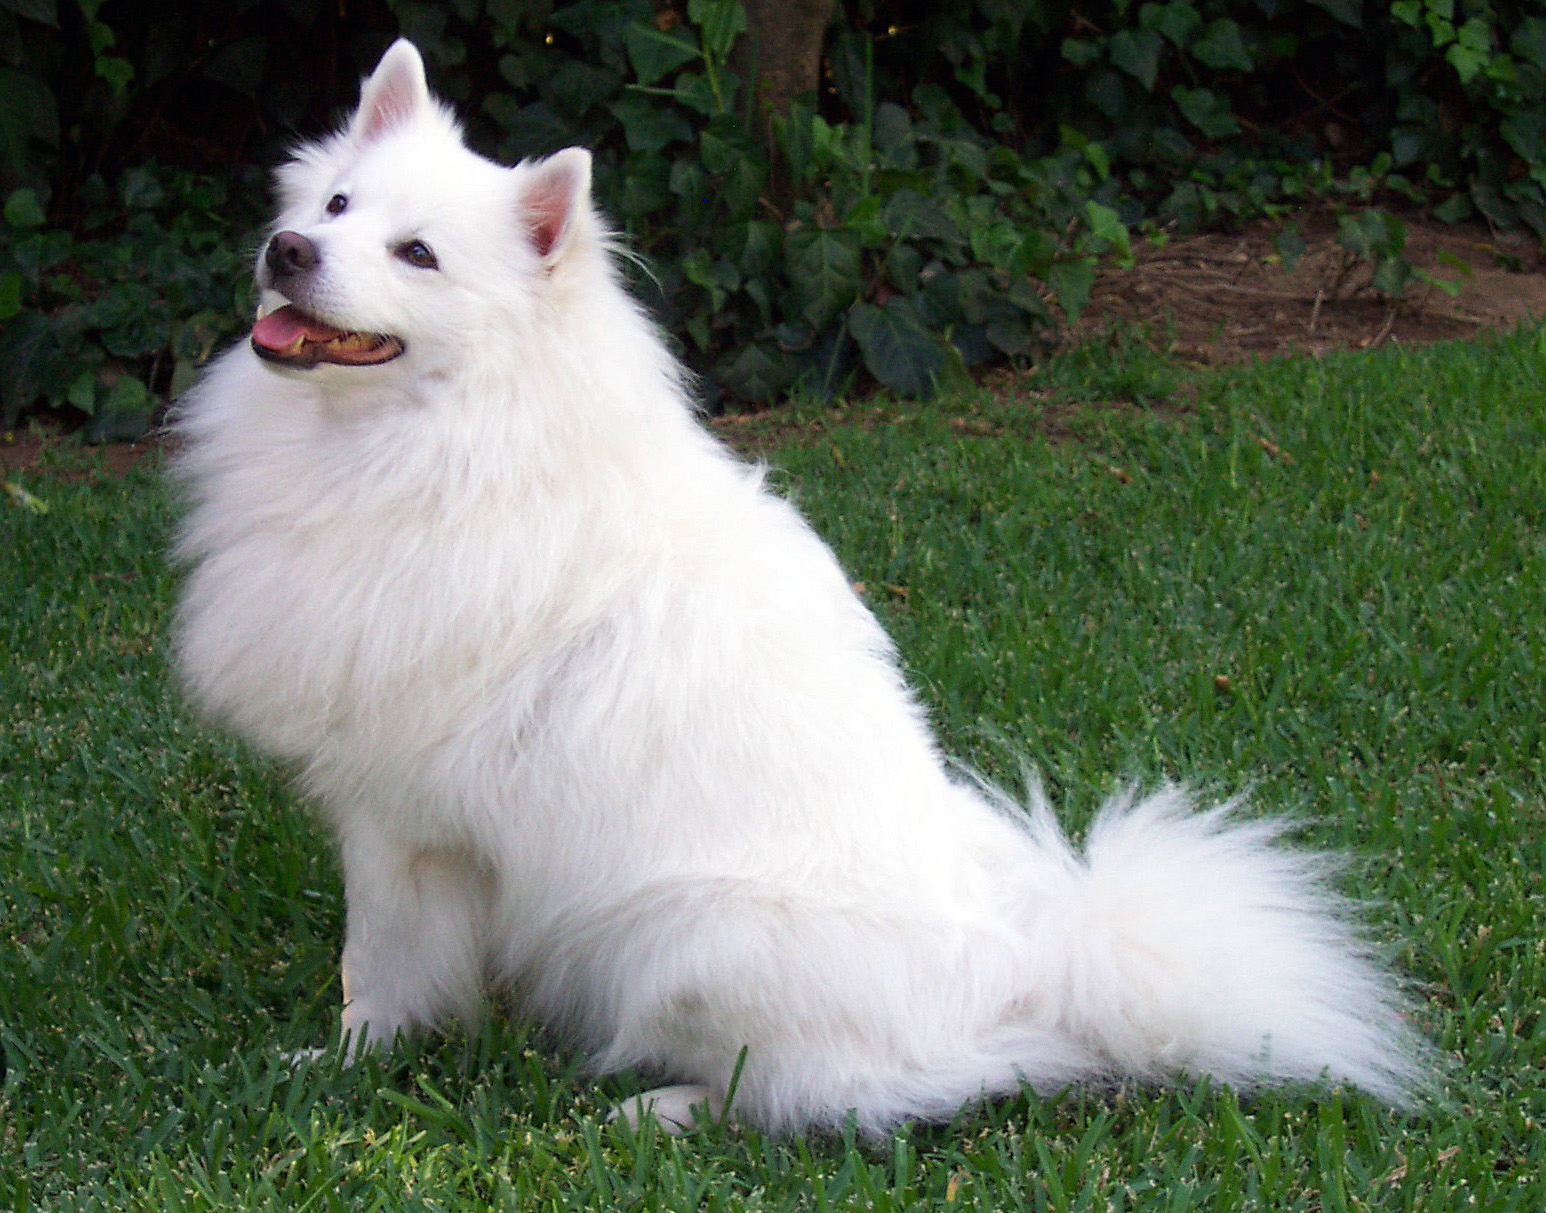

Kırpılmış (odaklanılan) bölge:


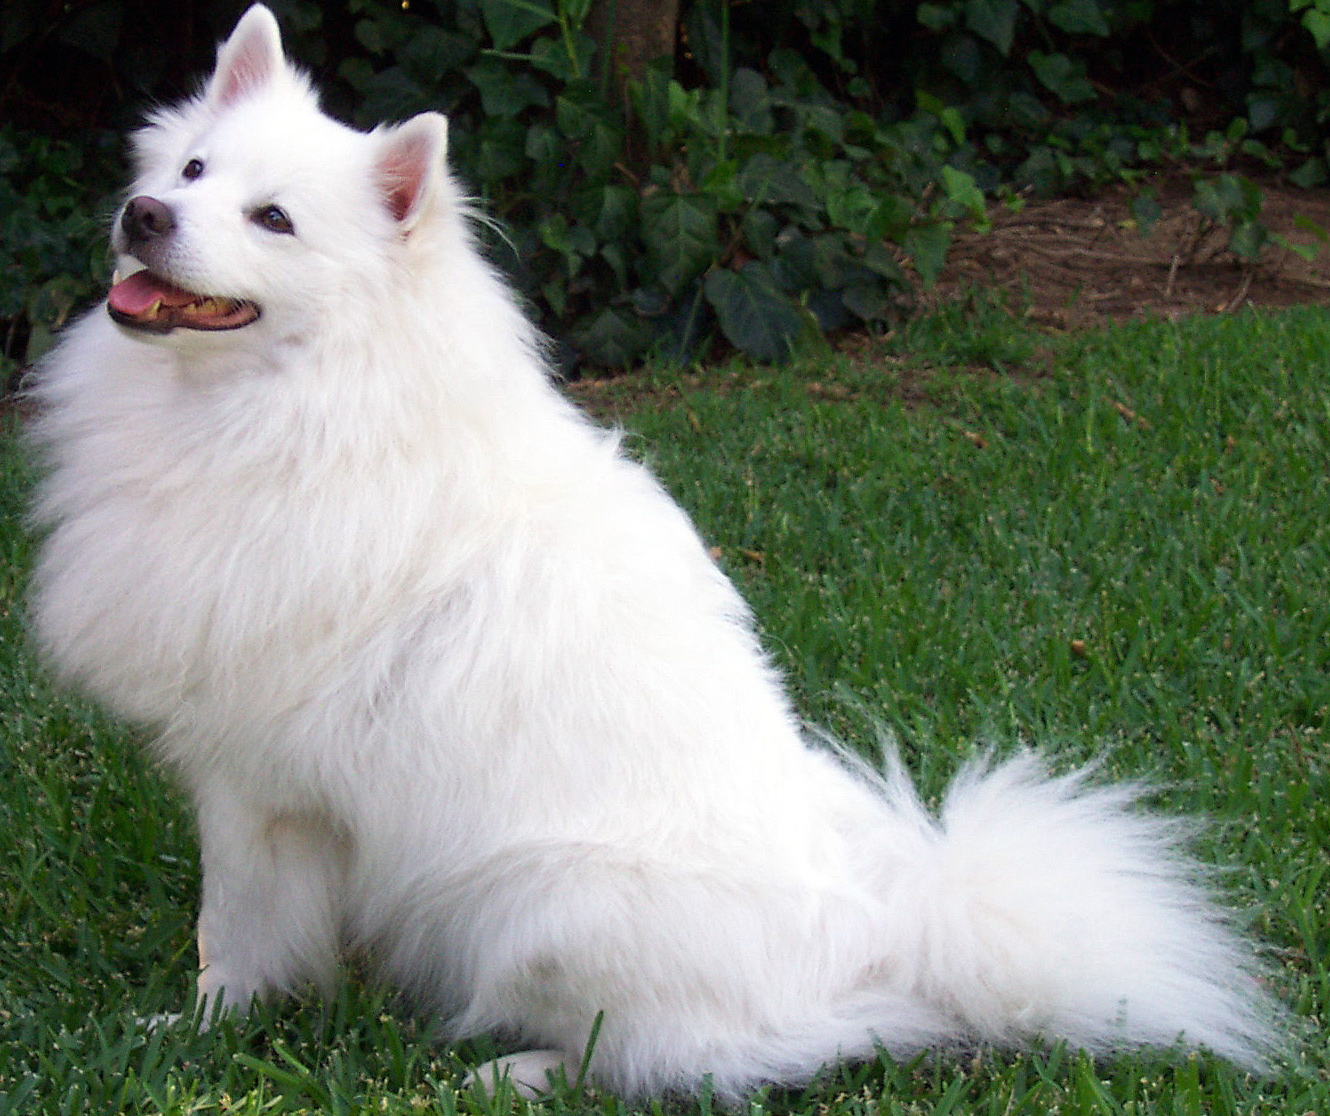

Tespit edilen obje: dog (güven: 93.20%)
En olası 5 sonuç:
  - dog: 93.20%
  - hot dog: 2.28%
  - teddy bear: 1.09%
  - blanket: 0.37%
  - yoga mat: 0.23%


In [ ]:
#Ayşenur/04-07-2026
GORUNTU_KAYNAGI = "https://github.com/pytorch/hub/raw/master/images/dog.jpg"

img = load_image(GORUNTU_KAYNAGI)
display(img)

# 1) Önce ön plandaki objeyi bul ve kırp
cropped_img = find_and_crop_foreground_object(img, GENIS_ETIKET_HAVUZU)
print("Kırpılmış (odaklanılan) bölge:")
display(cropped_img)

# 2) Kırpılmış bölgeyi CLIP ile sınıflandır
result = detect_object(cropped_img, GENIS_ETIKET_HAVUZU, label_embeddings=CACHED_LABEL_EMBEDDINGS)

print(f"Tespit edilen obje: {result.label} (güven: {result.confidence:.2%})")
print("En olası 5 sonuç:")
for label, score in result.top_k:
    print(f"  - {label}: {score:.2%}")

In [ ]:
#Ayşenur/05-07-2026
import nltk

nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.corpus import wordnet as wn

print("WordNet hazır.")

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


WordNet hazır.


In [ ]:
#Ayşenur/05-07-2026
# WordNet hiyerarşisinde çok üst seviyede yer alan, neredeyse her objeye
# uygulanabilecek kadar genel kelimeler. Bunlar anlamlı bir anahtar kelime
# olmadığı için (örn. "entity", "object") filtrelenip elenecek.
GENEL_KELIMELER = {
    "entity", "physical_entity", "abstraction", "abstract_entity",
    "object", "whole", "artifact", "artefact", "instrumentality",
    "instrumentation", "thing", "matter", "substance", "unit",
    "living_thing", "organism", "causal_agent", "physical_object",
    "psychological_feature", "event", "act", "activity", "content",
}


def _clean_word(lemma_name: str) -> str:
    """WordNet lemma isimlerindeki alt çizgileri boşluğa çevirir, küçük harfe indirir."""
    return lemma_name.replace("_", " ").lower()


def _find_primary_synset(object_label: str):
    """Obje ismi için en uygun WordNet synset'ini bulmaya çalışır.

    WordNet bazı kelimeler için "kişi" veya "eylem" anlamını fiziksel obje
    anlamından önce sıralayabiliyor (örn. "toaster" -> önce "kadeh kaldıran
    kişi", sonra "ekmek kızartma makinesi"). CLIP etiketlerimiz her zaman
    fiziksel bir nesneyi ifade ettiği için, "noun.person", "noun.act",
    "noun.communication" gibi fiziksel-olmayan kategorileri atlayıp, ilk
    fiziksel nesne (noun.artifact, noun.animal, noun.food, noun.plant vb.)
    anlamını tercih ediyoruz.
    """
    FIZIKSEL_OLMAYAN_KATEGORILER = {
        "noun.person", "noun.act", "noun.communication", "noun.cognition",
        "noun.state", "noun.event", "noun.attribute", "noun.group",
        "noun.process", "noun.relation", "noun.phenomenon",
    }

    candidates = [
        object_label.replace(" ", "_"),
        object_label.replace(" ", ""),
    ]
    words = object_label.split()
    if len(words) > 1:
        candidates.append(words[-1])

    for candidate in candidates:
        synsets = wn.synsets(candidate, pos=wn.NOUN)
        if not synsets:
            continue
        # Önce fiziksel nesne anlamı taşıyan ilk synset'i ara.
        for syn in synsets:
            if syn.lexname() not in FIZIKSEL_OLMAYAN_KATEGORILER:
                return syn
        # Hiçbiri uygun değilse, yine de ilk synset'i kullan (geri düşüş).
        return synsets[0]
    return None


def extract_keywords(object_label: str, max_keywords: int = 8) -> list:
    """Tespit edilen obje isminden WordNet kullanarak otomatik anahtar
    kelime çıkarır.

    Tasarım kararları (ilk denemeden sonra gözlemlenen sorunlara göre
    ayarlandı):
      - Hyponym'ler (alt kategoriler) DAHİL EDİLMİYOR: bunlar genelde çok
        spesifik/obscure ürün isimleri oluyor (örn. "chopine", "reuben"),
        proje örneklerindeki gibi geniş kategori kelimelerine (moda,
        aksesuar) benzemiyor.
      - Her synset'ten en fazla 2-3 lemma alınıyor: bazı synset'ler
        (örn. "nutrient") anormal derecede çok eş anlamlıya sahip, bunların
        hepsini almak listeyi aşırı soyut kelimelerle dolduruyor.
      - Büyük harfle başlayan lemma'lar (özel isim / bilimsel Latince isim,
        örn. "Canis_familiaris") filtreleniyor.
    """
    primary = _find_primary_synset(object_label)
    if primary is None:
        return []

    candidates = []

    # 1) Birincil synset'in eş anlamlıları (en fazla 3 tanesi)
    for lemma in primary.lemmas()[:3]:
        candidates.append(lemma.name())

    # 2) Üst kategoriler (2 seviyeye kadar, her synset'ten sınırlı lemma)
    for hyper in primary.hypernyms():
        for lemma in hyper.lemmas()[:2]:
            candidates.append(lemma.name())
        for hyper2 in hyper.hypernyms():
            candidates.append(hyper2.lemmas()[0].name())

    # Temizleme/filtreleme
    object_label_clean = object_label.lower()
    seen = set()
    filtered = []
    for raw_word in candidates:
        if raw_word[0].isupper():
            continue  # Özel isim / bilimsel isim (örn. Canis_familiaris)
        word = _clean_word(raw_word)
        if word == object_label_clean:
            continue
        if word in GENEL_KELIMELER:
            continue
        if word in seen:
            continue
        if len(word) < 3:
            continue
        seen.add(word)
        filtered.append(word)

    return filtered[:max_keywords]


print("extract_keywords fonksiyonu güncellendi (filtrelenmiş, hyponym'siz).")

extract_keywords fonksiyonu güncellendi (filtrelenmiş, hyponym'siz).


In [ ]:
#Ayşenur/05-07-2026
TEST_OBJELERI = ["backpack", "pizza", "sandwich", "cell phone", "shoe", "guitar"]

for obje in TEST_OBJELERI:
    kelimeler = extract_keywords(obje)
    print(f"{obje}: {kelimeler}")

backpack: ['back pack', 'knapsack', 'bag', 'container']
pizza: ['pizza pie', 'dish', 'nutriment']
sandwich: ['snack food', 'dish']
cell phone: ['cellular telephone', 'cellular phone', 'cellphone', 'radiotelephone', 'radiophone', 'telephone']
shoe: ['footwear', 'footgear', 'covering']
guitar: ['stringed instrument', 'musical instrument']


In [ ]:
#Ayşenur/05-07-2026
import json
import os
from datetime import datetime

VERITABANI_DOSYASI = "gorsel_sohbet_kayitlari.json"


def save_record(filepath: str, object_label: str, keywords: list, extra: dict = None) -> dict:
    """Obje adı, anahtar kelimeler ve zaman damgasını içeren bir kaydı
    JSON dosyasına ekler (append). Dosya yoksa oluşturur, varsa mevcut
    kayıtların üzerine değil, listenin sonuna ekler.

    JSON formatı doğası gereği "append-only" bir dosya biçimi değildir
    (tek bir liste/nesne olarak tutulur), bu yüzden her çağrıda dosyanın
    tamamını okuyup, yeni kaydı ekleyip, tekrar yazıyoruz. Küçük/orta
    ölçekli kullanım (bir sohbet oturumu) için bu performans açısından
    sorun teşkil etmez.
    """
    record = {
        "timestamp": datetime.now().isoformat(timespec="seconds"),
        "object": object_label,
        "keywords": keywords,
    }
    if extra:
        record.update(extra)

    if os.path.isfile(filepath):
        with open(filepath, "r", encoding="utf-8") as f:
            try:
                data = json.load(f)
            except json.JSONDecodeError:
                data = []  # Dosya bozuksa/boşsa güvenli başlangıç
    else:
        data = []

    data.append(record)

    with open(filepath, "w", encoding="utf-8") as f:
        json.dump(data, f, ensure_ascii=False, indent=2)

    return record


print("save_record fonksiyonu tanımlandı.")

save_record fonksiyonu tanımlandı.


In [ ]:
#Ayşenur/05-07-2026
class ChatSession:
    """Kullanıcıyla sohbet boyunca tespit edilen objeleri ve anahtar
    kelimeleri hafızada tutan basit bir sınıf.

    Bu sınıf, proje metninde belirtilen "daha önceden tespit edilen obje
    ismi ve anahtar kelimelerin de o anki aramada kullanılması ve böylece
    sohbet bağlamının sürdürülmesi" (artı puan) gereksinimini karşılamak
    için Gün 3'te web arama modülüyle birlikte kullanılacak.
    """

    def __init__(self):
        self._history = []  # [{"object": ..., "keywords": [...]}, ...]

    def add(self, object_label: str, keywords: list) -> None:
        """Yeni bir obje tespiti sonucunu geçmişe ekler."""
        self._history.append({"object": object_label, "keywords": keywords})

    def get_recent_keywords(self, n: int = 1) -> list:
        """Son n kayıttaki anahtar kelimeleri (tekrarsız) döndürür.

        Gün 3'te web araması yaparken, önceki obje(ler)in anahtar
        kelimelerini de düşük ağırlıkla mevcut sorguya ekleyerek bağlamı
        sürdürmek için kullanılacak.
        """
        recent = self._history[-n:] if n > 0 else []
        seen = set()
        combined = []
        for record in recent:
            for kw in record["keywords"]:
                if kw not in seen:
                    seen.add(kw)
                    combined.append(kw)
        return combined

    def __len__(self) -> int:
        return len(self._history)

    def __repr__(self) -> str:
        return f"ChatSession({len(self._history)} kayıt)"


print("ChatSession sınıfı tanımlandı.")

ChatSession sınıfı tanımlandı.


In [ ]:
#Ayşenur/05-07-2026
session = ChatSession()

GORUNTU_KAYNAGI = "https://github.com/pytorch/hub/raw/master/images/dog.jpg"

img = load_image(GORUNTU_KAYNAGI)
cropped_img = find_and_crop_foreground_object(img, GENIS_ETIKET_HAVUZU)
result = detect_object(cropped_img, GENIS_ETIKET_HAVUZU, label_embeddings=CACHED_LABEL_EMBEDDINGS)

keywords = extract_keywords(result.label)

record = save_record(VERITABANI_DOSYASI, result.label, keywords)
session.add(result.label, keywords)

print(f"Tespit edilen obje: {result.label} (güven: {result.confidence:.2%})")
print(f"Anahtar kelimeler: {keywords}")
print(f"JSON'a kaydedildi: {record}")
print(f"Sohbet geçmişi: {session}")

# JSON dosyasının içeriğini de kontrol edelim
with open(VERITABANI_DOSYASI, "r", encoding="utf-8") as f:
    print("\n--- JSON dosyası içeriği ---")
    print(f.read())

Tespit edilen obje: dog (güven: 93.20%)
Anahtar kelimeler: ['domestic dog', 'domestic animal', 'domesticated animal', 'animal', 'canine', 'canid', 'carnivore']
JSON'a kaydedildi: {'timestamp': '2026-07-07T16:09:31', 'object': 'dog', 'keywords': ['domestic dog', 'domestic animal', 'domesticated animal', 'animal', 'canine', 'canid', 'carnivore']}
Sohbet geçmişi: ChatSession(1 kayıt)

--- JSON dosyası içeriği ---
[
  {
    "timestamp": "2026-07-07T16:09:31",
    "object": "dog",
    "keywords": [
      "domestic dog",
      "domestic animal",
      "domesticated animal",
      "animal",
      "canine",
      "canid",
      "carnivore"
    ]
  }
]


In [ ]:
#Ayşenur/05-07-2026
!pip install -q ddgs beautifulsoup4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.7/161.7 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 103.3 MB/s eta 0:00:00


In [ ]:
#Ayşenur/05-07-2026
import requests
from bs4 import BeautifulSoup

# Paket ismi/import yolu sürüme göre değişebiliyor (ddgs / duckduckgo_search).
try:
    from ddgs import DDGS
except ImportError:
    from duckduckgo_search import DDGS

print("Web arama ve içerik çekme kütüphaneleri hazır.")

Web arama ve içerik çekme kütüphaneleri hazır.


In [ ]:
#Ayşenur/05-07-2026
def build_search_query(object_label: str, keywords: list, session: "ChatSession" = None,
                        use_context: bool = True, max_context_keywords: int = 2) -> str:
    """Obje adı ve anahtar kelimelerden bir arama sorgusu oluşturur.

    Proje metnindeki artı puan maddesi: "Daha önceden tespit edilen obje
    ismi ve anahtar kelimelerin de o anki aramada kullanılması ve böylece
    sohbet bağlamının sürdürülmesi." Bunu karşılamak için, eğer bir
    ChatSession verilmişse ve geçmişte kayıt varsa, önceki objenin
    anahtar kelimelerinden birkaçını da (düşük ağırlıkla, sadece
    max_context_keywords kadar) sorguya ekliyoruz. Böylece arama hem
    güncel objeye odaklı kalıyor hem de sohbetin önceki bağlamından
    hafifçe etkileniyor.
    """
    # Ana sorgu: obje adı + kendi anahtar kelimelerinin ilk birkaçı
    query_parts = [object_label] + keywords[:3]

    if use_context and session is not None and len(session) > 0:
        onceki_kelimeler = session.get_recent_keywords(n=1)
        # Şu anki objenin kendi kelimeleriyle çakışanları tekrar eklemiyoruz.
        yeni_baglam = [kw for kw in onceki_kelimeler if kw not in query_parts]
        query_parts += yeni_baglam[:max_context_keywords]

    return " ".join(query_parts)


print("build_search_query fonksiyonu tanımlandı.")

build_search_query fonksiyonu tanımlandı.


In [ ]:
#Ayşenur/05-07-2026
from urllib.parse import urlparse

# Alışveriş, sosyal medya ve video platformları genelde "obje hakkında
# açıklayıcı bilgi" değil, ürün listesi veya görsel içerik sunuyor.
# Proje metninin istediği "anlamlı metin" hedefiyle uyuşmadıkları için

DUSUK_KALITE_DOMAINLER = {
    "pinterest.com", "aliexpress.com", "amazon.com", "ebay.com", "etsy.com",
    "instagram.com", "facebook.com", "tiktok.com", "youtube.com", "temu.com",
}


def _dusuk_kalite_mi(url: str) -> bool:
    domain = urlparse(url).netloc.lower().replace("www.", "")
    return any(domain == d or domain.endswith("." + d) for d in DUSUK_KALITE_DOMAINLER)


def search_web(query: str, max_results: int = 5, filtrele: bool = True) -> list:
    """DuckDuckGo üzerinden metin araması yapar, sonuç listesini döndürür.

    filtrele=True ise, bilinen düşük-kaliteli (alışveriş/sosyal medya)
    domainler baştan elenir. Filtreleme sonrası yeterli sonuç kalmaması
    ihtimaline karşı, ham sonuç sayısını istenenin 2 katı kadar çekip
    filtreden sonra kırpıyoruz.
    """
    ham_sayisi = max_results * 2 if filtrele else max_results

    try:
        with DDGS() as ddgs:
            raw_results = list(ddgs.text(query, max_results=ham_sayisi))
    except Exception as exc:
        print(f"[Uyarı] Web araması başarısız oldu: {exc}")
        return []

    results = []
    for r in raw_results:
        url = r.get("href") or r.get("url", "")
        if filtrele and _dusuk_kalite_mi(url):
            continue
        results.append({
            "title": r.get("title", ""),
            "url": url,
            "snippet": r.get("body", ""),
        })

    return results[:max_results]


print("search_web fonksiyonu güncellendi (düşük kaliteli domain filtresi eklendi).")

search_web fonksiyonu güncellendi (düşük kaliteli domain filtresi eklendi).


In [ ]:
#Ayşenur/05-07-2026
def fetch_page_content(url: str, timeout: int = 10, max_chars: int = 2000, min_chars: int = 200) -> str:
    """Verilen URL'deki sayfanın ana metin içeriğini çeker ve temizler.

    min_chars'ın altında kalan içerikler (genelde JavaScript gerektiren
    veya erişim engellenmiş sayfaların kısa uyarı mesajları) anlamsız
    kabul edilip None olarak döndürülür.
    """
    headers = {"User-Agent": "Mozilla/5.0 (compatible; ProjeBot/1.0)"}

    try:
        response = requests.get(url, headers=headers, timeout=timeout)
        response.raise_for_status()
    except requests.RequestException as exc:
        print(f"[Uyarı] Sayfa alınamadı ({url}): {exc}")
        return None

    try:
        soup = BeautifulSoup(response.text, "html.parser")

        for tag in soup(["script", "style", "nav", "footer", "header", "aside", "form"]):
            tag.decompose()

        text = soup.get_text(separator=" ", strip=True)
        text = " ".join(text.split())

        if not text or len(text) < min_chars:
            print(f"[Uyarı] İçerik çok kısa/boş, muhtemelen erişim engelli ({url})")
            return None

        return text[:max_chars]
    except Exception as exc:
        print(f"[Uyarı] Sayfa içeriği ayrıştırılamadı ({url}): {exc}")
        return None


print("fetch_page_content fonksiyonu güncellendi (minimum uzunluk kontrolü eklendi).")

fetch_page_content fonksiyonu güncellendi (minimum uzunluk kontrolü eklendi).


In [ ]:
#Ayşenur/05-07-2026.


yeni_obje = "Cat"
yeni_kelimeler = extract_keywords(yeni_obje)

sorgu = build_search_query(yeni_obje, yeni_kelimeler, session=session)
print(f"Oluşturulan arama sorgusu: '{sorgu}'\n")

arama_sonuclari = search_web(sorgu, max_results=3)

if not arama_sonuclari:
    print("Hiç arama sonucu bulunamadı.")
else:
    for i, sonuc in enumerate(arama_sonuclari, 1):
        print(f"--- Sonuç {i}: {sonuc['title']} ---")
        print(f"URL: {sonuc['url']}")

        icerik = fetch_page_content(sonuc['url'])
        if icerik:
            print(f"İçerik (ilk 300 karakter): {icerik[:300]}...")
        else:
            print("İçerik çekilemedi, atlanıyor.")
        print()

# Bu objeyi de geçmişe ve JSON'a ekleyelim.
save_record(VERITABANI_DOSYASI, yeni_obje, yeni_kelimeler)
session.add(yeni_obje, yeni_kelimeler)
print(f"Sohbet geçmişi: {session}")

Oluşturulan arama sorgusu: 'Cat true cat feline felid domestic dog domestic animal'

--- Sonuç 1: Felidae - Wikipedia ---
URL: https://en.m.wikipedia.org/wiki/Felidae
İçerik (ilk 300 karakter): Felidae - Wikipedia Jump to content From Wikipedia, the free encyclopedia Family of mammals This article is about the biological family. For the film, see Felidae (film) . For the novel, see Felidae (novel) . "Felid" redirects here. For the city in Iran called Felīd, see Fildeh . This article may co...

--- Sonuç 2: Felis - Wikipedia ---
URL: https://en.m.wikipedia.org/wiki/Felis
İçerik (ilk 300 karakter): Felis - Wikipedia Jump to content From Wikipedia, the free encyclopedia Genus of mammals (cats) For other uses, see Felis (disambiguation) . Felis Temporal range: Piacenzian – Holocene , 3.4–0 Ma PreꞒ Ꞓ O S D C P T J K Pg N The six wild Felis species; from top-left, clockwise: European wildcat ( F. ...

--- Sonuç 3: Cat | Breeds, Origins, History, Body Types, Senses, Behavior ... ---
URL: http

In [ ]:
#Ayşenur/06-07-2026
!pip install -q scikit-learn

import nltk
nltk.download('punkt')
nltk.download('punkt_tab')  # Yeni nltk sürümlerinde ayrı bir kaynak olarak isteniyor

from nltk.tokenize import sent_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

print("Özetleme kütüphaneleri hazır.")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Özetleme kütüphaneleri hazır.


In [ ]:
#Ayşenur/06-07-2026
def summarize_text(text: str, num_sentences: int = 3) -> str:
    """Verilen metni, TF-IDF tabanlı extractive summarization ile özetler.

    Yöntem: Metni cümlelere ayırır, her cümlenin TF-IDF vektörünü
    hesaplar, cümlenin skorunu (vektöründeki kelime ağırlıklarının
    toplamı) bulur ve en yüksek skorlu N cümleyi seçer. Seçilen cümleler,
    metindeki orijinal sıralarıyla (kronolojik/mantıksal akış bozulmadan)
    birleştirilir.

    Bu, transformer tabanlı bir abstractive summarization modeli
    (örn. BART, T5) kullanmaktan daha hafif bir yaklaşımdır - ekstra bir
    büyük model indirmeye gerek kalmadan, metnin en "bilgi yoğun"
    cümlelerini çıkarır. Proje kapsamında zaten iki büyük model (CLIP,
    OWL-ViT) kullanıldığı için, özetleme adımında hafif bir yöntem tercih
    edilmiştir.
    """
    if not text or not text.strip():
        return ""

    sentences = sent_tokenize(text)

    # Metin zaten özet uzunluğunda veya daha kısaysa, olduğu gibi döndür.
    if len(sentences) <= num_sentences:
        return " ".join(sentences)

    try:
        vectorizer = TfidfVectorizer(stop_words="english")
        tfidf_matrix = vectorizer.fit_transform(sentences)
    except ValueError:
        # Çok kısa/anlamsız metinlerde TF-IDF boş kelime dağarcığı üretebilir.
        return " ".join(sentences[:num_sentences])

    # Her cümlenin skoru: TF-IDF vektöründeki ağırlıkların toplamı.
    sentence_scores = np.asarray(tfidf_matrix.sum(axis=1)).flatten()

    # En yüksek skorlu N cümlenin index'lerini bul, sonra orijinal sıraya göre diz.
    top_indices = sentence_scores.argsort()[-num_sentences:]
    top_indices_sorted = sorted(top_indices)

    summary = " ".join(sentences[i] for i in top_indices_sorted)
    return summary


print("summarize_text fonksiyonu tanımlandı.")

summarize_text fonksiyonu tanımlandı.


In [ ]:
#Ayşenur/06-07-2026
test_url = "https://en.wikipedia.org/wiki/Felidae"
test_icerik = fetch_page_content(test_url, max_chars=3000)

if test_icerik:
    print("--- Orijinal içerik (ilk 500 karakter) ---")
    print(test_icerik[:500])
    print(f"\n(Toplam {len(test_icerik)} karakter)\n")

    ozet = summarize_text(test_icerik, num_sentences=3)
    print("--- Özet (3 cümle) ---")
    print(ozet)
else:
    print("İçerik çekilemedi, farklı bir URL dene.")

--- Orijinal içerik (ilk 500 karakter) ---
Felidae - Wikipedia Jump to content From Wikipedia, the free encyclopedia Family of mammals This article is about the biological family. For the film, see Felidae (film) . For the novel, see Felidae (novel) . "Felid" redirects here. For the city in Iran called Felīd, see Fildeh . This article may contain an excessive number of citations . Please help improve it by removing low-quality or irrelevant citations or redistributing those citations so there are fewer than four in a row. ( September 202

(Toplam 3000 karakter)

--- Özet (3 cümle) ---
( September 2025 ) ( Learn how and when to remove this message ) Felidae [ 1 ] Temporal range: Oligocene – Present , 30.8–0 Ma [ 2 ] PreꞒ Ꞓ O S D C P T J K Pg N Tiger Canada lynx Asian golden cat Ocelot Serval Cougar Fishing cat European wildcat Scientific classification Kingdom: Animalia Phylum: Chordata Class: Mammalia Infraclass: Placentalia Order: Carnivora Superfamily: Feloidea Family: Felidae Fische

In [ ]:
#Ayşenur/06-07-2026
def process_image(image_source: str, session: "ChatSession", label_pool: list,
                   label_embeddings, max_search_results: int = 3) -> dict:
    """Bir görüntü kaynağından (URL/dosya yolu) başlayıp, obje tespiti,
    anahtar kelime çıkarımı, web araması, içerik çekme, özetleme ve
    kayıt adımlarının tamamını uçtan uca çalıştırır.

    Proje metninin ana akışının (girdi -> analiz -> arama -> özet ->
    gösterim -> kayıt) tek bir fonksiyonda toplanmış hali. main.py'deki
    CLI döngüsü bu fonksiyonu her kullanıcı girdisinde bir kez çağıracak.

    Returns:
        Kullanıcıya gösterilecek/loglanacak tüm bilgileri içeren bir sözlük.
    """
    # 1) Görüntüyü yükle ve ön plandaki objeyi bul
    image = load_image(image_source)
    cropped = find_and_crop_foreground_object(image, label_pool)

    # 2) Objeyi sınıflandır
    detection = detect_object(cropped, label_pool, label_embeddings=label_embeddings)

    # 3) Anahtar kelimeleri çıkar
    keywords = extract_keywords(detection.label)

    # 4) Bağlamı da kullanarak arama sorgusu oluştur, web'de ara
    query = build_search_query(detection.label, keywords, session=session)
    search_results = search_web(query, max_results=max_search_results)

    # 5) İlk başarılı sonuçtan içerik çek ve özetle (birden fazla deneyebiliriz)
    summary = None
    kaynak_url = None
    for result in search_results:
        content = fetch_page_content(result["url"])
        if content:
            summary = summarize_text(content, num_sentences=3)
            kaynak_url = result["url"]
            break  # İlk başarılı sonuç yeterli

    # 6) Kaydet ve sohbet geçmişine ekle
    save_record(
        VERITABANI_DOSYASI, detection.label, keywords,
        extra={"query": query, "summary": summary, "source_url": kaynak_url},
    )
    session.add(detection.label, keywords)

    return {
        "object": detection.label,
        "confidence": detection.confidence,
        "keywords": keywords,
        "query": query,
        "summary": summary,
        "source_url": kaynak_url,
    }


print("process_image fonksiyonu tanımlandı.")

process_image fonksiyonu tanımlandı.


**ARAYÜZ KODU URL LER BURAYA EKLENİYOR**

In [ ]:
#Ayşenur/06-07-2026
def run_chat_loop():
    """Kullanıcıdan sürekli görüntü kaynağı alan, her seferinde process_image
    çalıştırıp sonucu gösteren döngü. 'q' veya 'cikis' yazılana kadar devam
    eder (proje metni: 'kullanıcı uygulamayı sonlandırasıya kadar akış
    devam etmelidir').
    """
    print("Görüntülü Sohbet Uygulaması - çıkmak için 'q' veya 'cikis' yazın.\n")

    while True:
        kaynak = input("Görüntü URL'si veya dosya yolu: ").strip()

        if kaynak.lower() in ("q", "cikis"):
            print("Görüşmek üzere , bay")
            break

        if not kaynak:
            continue

        try:
            sonuc = process_image(kaynak, session, GENIS_ETIKET_HAVUZU, CACHED_LABEL_EMBEDDINGS)
        except ValueError as exc:
            print(f"[Hata] {exc}\n")
            continue

        print(f"\nTespit edilen obje: {sonuc['object']} (güven: {sonuc['confidence']:.2%})")
        print(f"Anahtar kelimeler: {', '.join(sonuc['keywords'])}")
        if sonuc['summary']:
            print(f"\nObje hakkında: {sonuc['summary']}")
            print(f"(Kaynak: {sonuc['source_url']})")
        else:
            print("\n(Web'den anlamlı bir içerik bulunamadı.)")
        print("-" * 60 + "\n")
#https://en.wikipedia.org/wiki/Felidae

# Çalıştırmak için:
run_chat_loop()

Görüntülü Sohbet Uygulaması - çıkmak için 'q' veya 'cikis' yazın.

Görüntü URL'si veya dosya yolu: https://github.com/pytorch/hub/raw/master/images/dog.jpg

Tespit edilen obje: dog (güven: 93.20%)
Anahtar kelimeler: domestic dog, domestic animal, domesticated animal, animal, canine, canid, carnivore

Obje hakkında: [ 1 ] : 84 Several investigations have shown that all domestic varieties of cats come from a single lineage of F. lybica , although early interactions between wildcats and Neolithic human settlements occurred across a broad geographic range. [ 2 ] Originating in the Near East , the first domestic cats spread from the ancient Mediterranean world via maritime trade as well as the Silk road , and later worldwide through European colonization . Advances in paleogenomics and the sequencing of ancient nuclear DNA has greatly helped revise the history of ancient cats, which could otherwise be hard to decipher due to ancient hybridization between morphologically similar wild species

In [ ]:
import json
import torch.nn as nn

# Gün 5'teki MLPHead mimarisini burada da tanımlıyoruz (aynı yapı olmalı,
# yoksa kaydedilen ağırlıklar yüklenemez).
class MLPHead(nn.Module):
    def __init__(self, embedding_dim, num_classes, hidden_dim=512):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(embedding_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, x):
        return self.net(x)


with open("class_names.json", "r", encoding="utf-8") as f:
    EGITILMIS_SINIF_ISIMLERI = json.load(f)

EMBEDDING_DIM = 768  # ViT-L/14'ün visual_projection çıktı boyutu
trained_head_model = MLPHead(EMBEDDING_DIM, len(EGITILMIS_SINIF_ISIMLERI)).to(device)
trained_head_model.load_state_dict(torch.load("linear_head_weights.pth", map_location=device))
trained_head_model.eval()

print(f"Eğitilmiş model yüklendi: {len(EGITILMIS_SINIF_ISIMLERI)} sınıf")

Eğitilmiş model yüklendi: 257 sınıf


In [ ]:
import re

def clean_class_name(raw_name: str) -> str:
    """'003.backpack' -> 'backpack', '145.motorbikes-101' -> 'motorbikes' """
    without_number = re.sub(r"^\d+\.", "", raw_name)
    without_suffix = re.sub(r"-\d+$", "", without_number)  # '-101' gibi ekleri de temizle
    return without_suffix.replace("-", " ")


print(clean_class_name("003.backpack"))       # backpack
print(clean_class_name("145.motorbikes-101")) # motorbikes
print(clean_class_name("257.clutter"))        # clutter

backpack
motorbikes
clutter


In [ ]:
EGITIM_GUVEN_ESIGI = 0.6  # Bu eşiğin altında, eğitilmiş modelin "emin değil" kabul ediyoruz


def hybrid_detect_object(image: Image.Image, label_pool: list, label_embeddings) -> dict:
    """CLIP zero-shot ile eğitilmiş MLP modelini birleştiren hibrit tespit.

    Tasarım mantığı: CLIP'in softmax güveni ile MLP'nin softmax güveni
    doğrudan karşılaştırılamaz (farklı sayıda sınıf üzerinden hesaplanıyorlar,
    ölçekleri farklı). Bu yüzden "hangisi daha yüksek güven veriyorsa o
    kazansın" yerine, MLP'nin KENDİ güvenini KENDİ eşiğine göre
    değerlendiriyoruz: MLP güveni yüksekse (EGITIM_GUVEN_ESIGI üzerinde),
    bu objenin muhtemelen onun eğitim kapsamına (257 Caltech-256 sınıfı)
    girdiği ve tahmininin güvenilir olduğu anlamına gelir. Düşükse, obje
    muhtemelen kapsam dışıdır ve sadece CLIP'in genel-amaçlı zero-shot
    sonucuna güvenilir.

    Her iki model de AYNI CLIP embedding'ini (image_features) kullanır -
    bu hem hesaplama tasarrufu sağlar hem de "iki farklı görüşün aynı
    temsil üzerinden geldiğini" garanti eder.
    """
    with torch.no_grad():
        image_features = _get_image_embedding(image)
        image_features_normalized = image_features / image_features.norm(dim=-1, keepdim=True)

        # 1) CLIP zero-shot (ana sistem, her zaman çalışır)
        logit_scale = model.logit_scale.exp()
        clip_logits = logit_scale * image_features_normalized @ label_embeddings.T
        clip_probs = clip_logits.softmax(dim=1)[0]
        clip_best_idx = clip_probs.argmax().item()
        clip_label = label_pool[clip_best_idx]
        clip_confidence = clip_probs[clip_best_idx].item()

        # 2) Eğitilmiş MLP (aynı embedding üzerinde, normalize edilmemiş hali ile)
        mlp_logits = trained_head_model(image_features)
        mlp_probs = mlp_logits.softmax(dim=1)[0]
        mlp_best_idx = mlp_probs.argmax().item()
        mlp_raw_label = EGITILMIS_SINIF_ISIMLERI[mlp_best_idx]
        mlp_confidence = mlp_probs[mlp_best_idx].item()
        mlp_label = clean_class_name(mlp_raw_label)

    # Karar mantığı: MLP kendi eşiğinin üzerindeyse, onun sonucunu
    # "kapsam içi ve güvenilir" kabul edip nihai etiket olarak kullanıyoruz.
    if mlp_confidence >= EGITIM_GUVEN_ESIGI and clean_class_name(mlp_raw_label) != "clutter":
        final_label = mlp_label
        kaynak = "egitilmis_model"
    else:
        final_label = clip_label
        kaynak = "clip_zero_shot"

    return {
        "final_label": final_label,
        "kaynak": kaynak,
        "clip_label": clip_label,
        "clip_confidence": clip_confidence,
        "mlp_label": mlp_label,
        "mlp_confidence": mlp_confidence,
        "modeller_hemfikir_mi": clip_label.lower() in mlp_label.lower() or mlp_label.lower() in clip_label.lower(),
    }


print("hybrid_detect_object fonksiyonu tanımlandı.")

hybrid_detect_object fonksiyonu tanımlandı.


In [ ]:
# Test 1: Eğitilmiş modelin kapsamında olan bir obje (backpack, Caltech-256'da var)
img1 = load_image("http://images.cocodataset.org/val2017/000000039769.jpg")  # kediler
cropped1 = find_and_crop_foreground_object(img1, GENIS_ETIKET_HAVUZU)
sonuc1 = hybrid_detect_object(cropped1, GENIS_ETIKET_HAVUZU, CACHED_LABEL_EMBEDDINGS)
print("--- Test 1 ---")
for k, v in sonuc1.items():
    print(f"  {k}: {v}")

print()

# Test 2: Köpek
img2 = load_image("https://github.com/pytorch/hub/raw/master/images/dog.jpg")
cropped2 = find_and_crop_foreground_object(img2, GENIS_ETIKET_HAVUZU)
sonuc2 = hybrid_detect_object(cropped2, GENIS_ETIKET_HAVUZU, CACHED_LABEL_EMBEDDINGS)
print("--- Test 2 ---")
for k, v in sonuc2.items():
    print(f"  {k}: {v}")

--- Test 1 ---
  final_label: sofa
  kaynak: clip_zero_shot
  clip_label: sofa
  clip_confidence: 0.8096744418144226
  mlp_label: dog
  mlp_confidence: 0.3963259160518646
  modeller_hemfikir_mi: False

--- Test 2 ---
  final_label: dog
  kaynak: egitilmis_model
  clip_label: dog
  clip_confidence: 0.9319533109664917
  mlp_label: dog
  mlp_confidence: 0.9941273927688599
  modeller_hemfikir_mi: True
